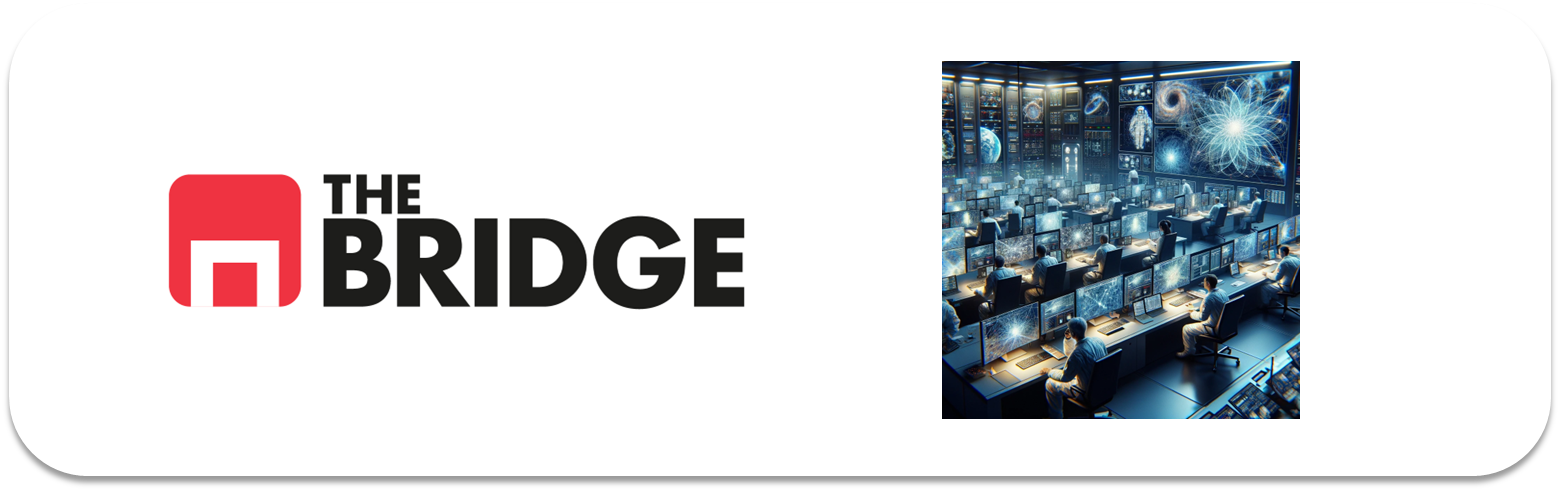

## PRACTICA OBLIGATORIA: **Redes Convolucionales**

* La práctica obligatoria de esta unidad consiste en un ejercicio de construcción de una red convolucional con Keras para la clasificación de imagenes de simpáticos perretes y gatetes. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
# --- Manejo de datos y ficheros ---
import os
import numpy as np
import pandas as pd

# --- Lectura y redimensionado de imagenes ---
from skimage.io import imread
import cv2

# --- Visualizacion ---
import matplotlib.pyplot as plt
import seaborn as sns
import bootcampviztools as bt          # utilidades de visualizacion del bootcamp

# --- Utilidades de sklearn ---
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

# --- Keras / Deep Learning ---
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Input, Conv2D, MaxPooling2D, Dropout, Flatten, Dense
from keras.layers import RandomFlip, RandomRotation, RandomZoom
from keras.optimizers import Adam
from keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings("ignore")

# Fijamos las semillas para que el notebook sea reproducible
SEMILLA = 42
np.random.seed(SEMILLA)
tf.random.set_seed(SEMILLA)

print("TensorFlow:", tf.__version__)

TensorFlow: 2.21.0


### Problema de Negocio y dataset

Una conocida empresa de información inmobiliaria utiliza un CAPTCHA visual de perros y gatos para detectar webscrappings intensivos y ataques de denegación de servicio. Últimamente, ha detectado que su sistema está empezando a flojear, es decir que hay muchos sistemas de detección automática de imágenes que son capaces de detectar que es un perro y un gato y salterse el CAPTCHA antirobots. Por eso nos ha pedido que entrenemos un modelo potente de clasificación que emule a estos sistemas con el objetivo de emplear como fotografías para el CAPTCHA aquellas que no sepa detectar este sistema emulador de chicos malos.  

Pues manos a la obra, tenemos que seleccionar en un conjunto de 1000 imágenes aquellas que peor se le daría clasificar a un potencial sistema anti-CAPTCHA.  

Para ello vamos a emplear un conjunto de train de 4000 imágenes de perretes y gatetes que se encuentran distribuidas en "data" en cuatro directorios "github_train_0",  "github_train_1", "githun_train_2" y "github_train_3". Los datos de las imagenes que tenemos que clasificar y luego seleccionar como las más "difíciles" están en "data" en el directorio "github_test".


### Se pide

1. Crear los datasets X,y de train y test, leyendo las imágenes de los directorios correspondientes (tendrás que leer todas las imágenes de los cuatro directorios para train) y a la vez que se leen adpatar su resolución para que todas tengan un tamaño de 32x32. En este caso puedes adaptar las funciones de los ejercicios de la unidad. NOTA: Ten en cuenta que la clase a la que pertenece en la foto está en el nombre del archivo.

2. Crea un modelo DL basado en redes convolucionales con al menos dos juegos Convolucional-Pooling. Sigue todo el proceso de ML (visualización del dataset, MiniEDA, Construcción del modelo)

3. Entrenar el modelo con un callback de Earlystopping con paciencia la que tengas :-). Muestra su historial de entrenamiento.

4. Evalua el modelo, haz un reporte de clasificacion y muestra la matriz de confianza.

5. Es el momento de seleccionar las imagenes: Selecciona el 10% de imágenes mal clasificadas de una y otra clase que tengan el mayor nivel de confianza de que pertenencían a la clase errónea. Es decir las imágenes de perros clasificadas como gatos y con la probabilidad de ser perror más alta.


### Extra (para hacer en clase)

Repite los pasos 3 a 5 utilizando el generador de imágenes sintéticas o Image Augmentation de Keras. 



***
## 1. Crear los datasets X, y de train y test

Antes de escribir la función de carga miramos cómo están organizados los datos,
porque el enunciado avisa de un detalle importante: **la clase está en el nombre
del archivo**, no en el nombre de la carpeta.

In [2]:
RUTA_DATOS = "./data/"
DIRS_TRAIN = [RUTA_DATOS + f"github_train_{i}" for i in range(4)]
DIR_TEST = RUTA_DATOS + "github_test"

# Vemos cuantos archivos hay en cada directorio y como se llaman
for directorio in DIRS_TRAIN + [DIR_TEST]:
    ficheros = os.listdir(directorio)
    # La clase es lo que va antes del primer punto: "cat.1000.jpg" -> "cat"
    clases = pd.Series([f.split(".")[0] for f in ficheros]).value_counts().to_dict()
    print(f"{directorio:28} {len(ficheros):5} imagenes  ->  {clases}")

./data/github_train_0         1000 imagenes  ->  {'cat': 1000}
./data/github_train_1         1000 imagenes  ->  {'cat': 1000}
./data/github_train_2         1000 imagenes  ->  {'dog': 1000}
./data/github_train_3         1000 imagenes  ->  {'dog': 1000}
./data/github_test            1000 imagenes  ->  {'cat': 500, 'dog': 500}


Aquí aparece **el primer aviso importante**: los directorios de train no están
mezclados. `github_train_0` y `github_train_1` son 2000 gatos, y `github_train_2`
y `github_train_3` son 2000 perros. Es decir, si los leemos en orden tendremos
todos los gatos primero y todos los perros después.

Lo apuntamos porque nos va a obligar a **barajar los datos** antes de entrenar
(volvemos sobre esto en el paso 2).

Vamos ahora con la función de carga. Es la función `read_data` de los ejercicios
de la unidad, adaptada en dos cosas:

1. Puede recibir **una lista de directorios**, porque el train está repartido en cuatro.
2. La etiqueta la saca **del nombre del fichero** en lugar del nombre de la carpeta.

Devolvemos también los nombres de los ficheros, que nos harán falta en el paso 5
para identificar las imágenes que seleccionemos para el CAPTCHA.

In [3]:
def read_data(directorios, reshape_dim=(32, 32)):
    """Lee las imagenes de uno o varios directorios y las redimensiona.

    La clase se obtiene del nombre del fichero (p.ej. "cat.1000.jpg" -> "cat").

    Args:
        directorios: ruta (str) o lista de rutas de los directorios a leer.
        reshape_dim: tupla (ancho, alto) al que se redimensionan las imagenes.

    Returns:
        X: array de imagenes, shape (n_imagenes, alto, ancho, 3)
        y: array con la clase de cada imagen ("cat" / "dog")
        nombres: array con el nombre del fichero de cada imagen
    """
    X = []
    y = []
    nombres = []

    # Si nos pasan un solo directorio lo metemos en una lista para poder iterar igual
    if isinstance(directorios, str):
        directorios = [directorios]

    for directorio in directorios:
        # sorted() para que el orden sea siempre el mismo en cada ejecucion
        for fichero in sorted(os.listdir(directorio)):
            if not fichero.lower().endswith(".jpg"):
                continue

            imagen = imread(os.path.join(directorio, fichero))
            imagen = cv2.resize(imagen, reshape_dim)   # todas a 32x32

            X.append(imagen)
            y.append(fichero.split(".")[0])            # la clase esta en el nombre
            nombres.append(fichero)

    return np.array(X), np.array(y), np.array(nombres)

La lanzamos sobre los cuatro directorios de train y sobre el de test. Tarda unos
segundos porque son 5000 imágenes que hay que abrir y redimensionar una a una.

In [4]:
RESHAPE_DIM = (32, 32)

X_train, y_train, nombres_train = read_data(DIRS_TRAIN, RESHAPE_DIM)
X_test, y_test, nombres_test = read_data(DIR_TEST, RESHAPE_DIM)

print("TRAIN -> X:", X_train.shape, "| y:", y_train.shape)
print("TEST  -> X:", X_test.shape, "| y:", y_test.shape)

TRAIN -> X: (4000, 32, 32, 3) | y: (4000,)
TEST  -> X: (1000, 32, 32, 3) | y: (1000,)


Las dimensiones son las que esperábamos: `(n_imagenes, 32, 32, 3)`. El último 3
son los **canales RGB**, porque estas fotos son en color (a diferencia del MNIST
del workout, que era en escala de grises y tenía un solo canal).

Comprobamos también la escala de los valores y que no haya nada raro:

In [5]:
print("Tipo de dato:", X_train.dtype)
print("Valor minimo:", X_train.min(), "| Valor maximo:", X_train.max())
print("Hay algun NaN?:", np.isnan(X_train).any())
print()
print("Clases en train:", np.unique(y_train))
print("Clases en test :", np.unique(y_test))

Tipo de dato: uint8
Valor minimo: 0 | Valor maximo: 255
Hay algun NaN?: False

Clases en train: ['cat' 'dog']
Clases en test : ['cat' 'dog']


Valores enteros de 0 a 255 (los tres canales de color), sin datos ausentes. Habrá
que escalar dividiendo por 255, como en el workout.

***
## 2. Visualización, MiniEDA y construcción del modelo

### 2.1 Visualización del dataset

Como en el workout, lo primero al trabajar con imágenes es tener una función para
verlas. Adaptamos `plot_digits` del workout: ahora las imágenes son en color, así
que quitamos el `cmap="Greys"` y dejamos que matplotlib pinte el RGB.

In [6]:
def plot_imagenes(imagenes, etiquetas=None, n_cols=5, titulo=None):
    """Pinta un conjunto de imagenes en una rejilla, con su etiqueta encima.

    Args:
        imagenes: array de imagenes (n, alto, ancho, 3).
        etiquetas: lista/array de textos a poner como titulo de cada imagen.
        n_cols: numero de columnas de la rejilla.
        titulo: titulo general de la figura.
    """
    n_filas = (len(imagenes) - 1) // n_cols + 1
    plt.figure(figsize=(n_cols * 2, n_filas * 2.3))

    for indice, imagen in enumerate(imagenes):
        plt.subplot(n_filas, n_cols, indice + 1)
        plt.imshow(imagen)
        plt.axis("off")
        if etiquetas is not None:
            plt.title(etiquetas[indice], fontsize=9)

    if titulo:
        plt.suptitle(titulo, fontsize=13)
    plt.tight_layout()
    plt.show()

Miramos una muestra aleatoria de train. Usamos una muestra aleatoria y no las
primeras porque, como ya hemos visto, las primeras son todas gatos.

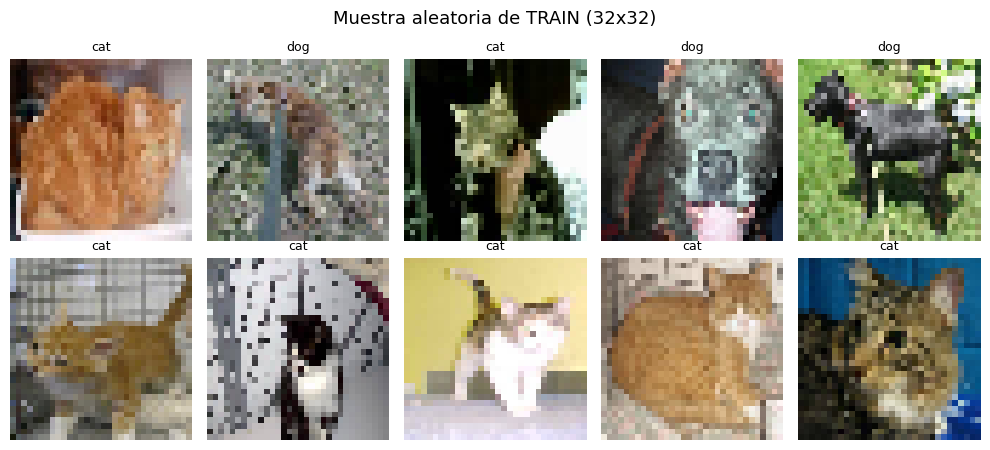

In [7]:
indices_muestra = np.random.choice(len(X_train), 10, replace=False)
plot_imagenes(X_train[indices_muestra], y_train[indices_muestra],
              titulo="Muestra aleatoria de TRAIN (32x32)")

A 32x32 las imágenes se ven **muy pixeladas**. Se distingue que hay un animal,
pero decir si es perro o gato es difícil incluso para nosotros. Esto ya nos avisa
de que no vamos a conseguir el 99% de accuracy del MNIST: es un problema mucho
más duro. Lo cual, para el objetivo de negocio, no es del todo malo (queremos
encontrar imágenes difíciles).

Vemos también una muestra del test, que es el conjunto del que tendremos que
seleccionar las imágenes del CAPTCHA:

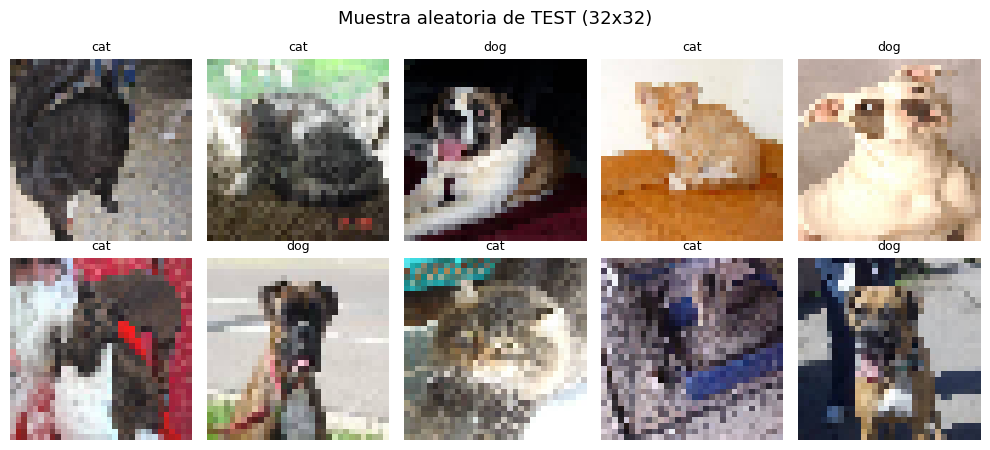

In [8]:
indices_muestra_test = np.random.choice(len(X_test), 10, replace=False)
plot_imagenes(X_test[indices_muestra_test], y_test[indices_muestra_test],
              titulo="Muestra aleatoria de TEST (32x32)")

### 2.2 MiniEDA

Con imágenes el EDA se reduce bastante: lo importante es **la distribución del
target**, porque de ella depende la métrica que podemos usar. Lo pintamos con
`pinta_distribucion_categoricas` de `bootcampviztools`, igual que en el workout.

La función espera un DataFrame, así que montamos uno con las etiquetas.

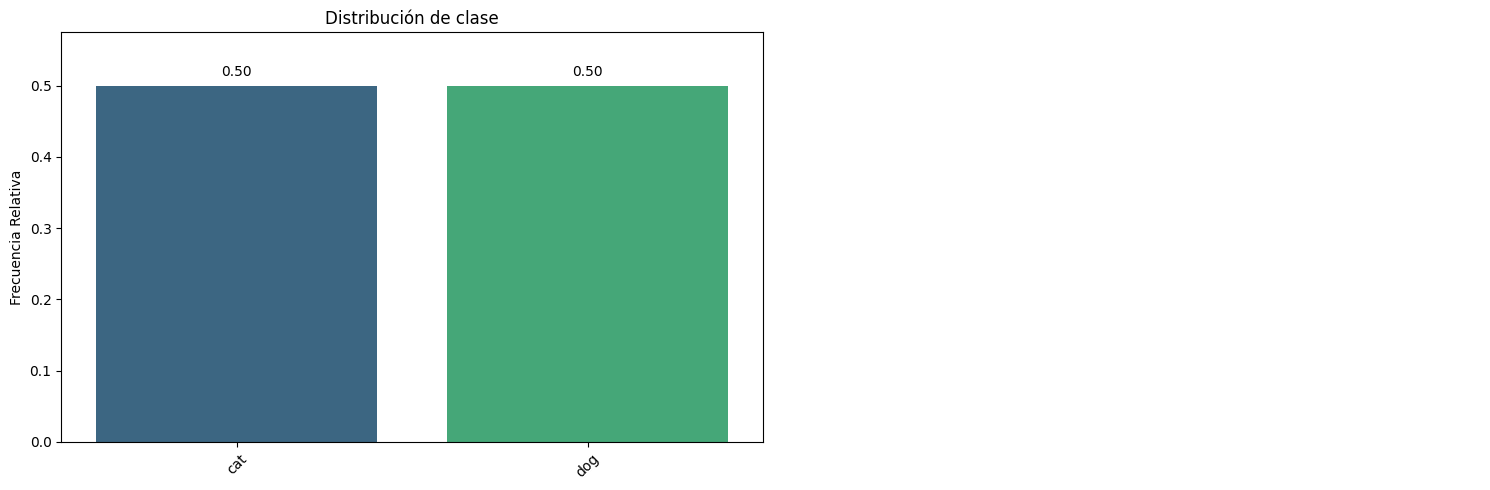

In [9]:
# bootcampviztools trabaja con DataFrames, montamos uno con las etiquetas
df_train = pd.DataFrame({"clase": y_train})
df_test = pd.DataFrame({"clase": y_test})

bt.pinta_distribucion_categoricas(df_train, ["clase"], relativa=True, mostrar_valores=True)

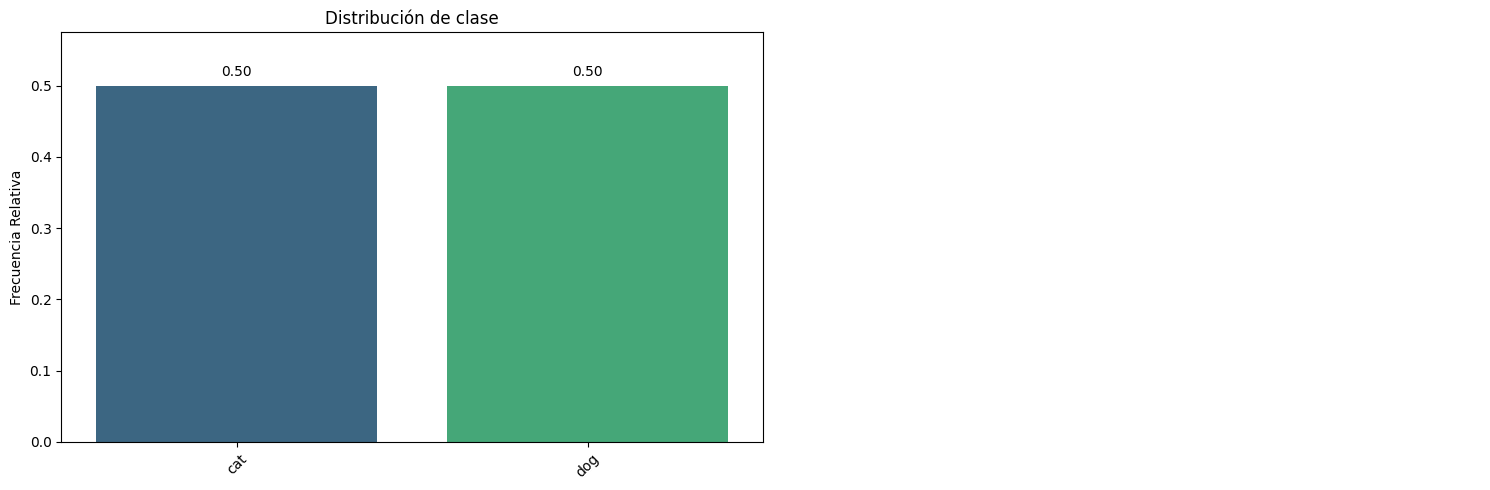

In [10]:
bt.pinta_distribucion_categoricas(df_test, ["clase"], relativa=True, mostrar_valores=True)

**Conclusión del miniEDA**: los dos conjuntos están perfectamente equilibrados al
50/50 (2000 gatos y 2000 perros en train, 500 y 500 en test). Por tanto:

* Podemos usar **`accuracy`** como métrica de entrenamiento y validación sin
  preocuparnos, igual que en el workout.
* El azar está en el 50%. Pero ese es un suelo muy pobre para juzgar el modelo, así
  que en el apartado 2.4 montaremos un baseline mucho más exigente.

### 2.3 Transformación de features

Tres cosas que hacer, en este orden:

1. **Pasar las etiquetas a número**: Keras no acepta etiquetas de texto. Creamos
   los dos diccionarios de traducción (uno en cada sentido) para poder volver a
   los nombres cuando toque interpretar resultados.
2. **Escalar**: dividimos por 255, el truco del workout.
3. **Barajar**: es el paso que detectamos en el punto 1 y el más fácil de olvidar.

In [11]:
# 1. Etiquetas a numero. Guardamos los dos diccionarios de traduccion.
clase_a_numero = {"cat": 0, "dog": 1}
numero_a_clase = {v: k for k, v in clase_a_numero.items()}
NOMBRES_CLASES = ["cat", "dog"]          # indice 0 -> cat, indice 1 -> dog

y_train_num = np.array([clase_a_numero[c] for c in y_train])
y_test_num = np.array([clase_a_numero[c] for c in y_test])

print("clase_a_numero:", clase_a_numero)
print("numero_a_clase:", numero_a_clase)
print("y_train_num:", y_train_num[:5], "...", y_train_num[-5:])

clase_a_numero: {'cat': 0, 'dog': 1}
numero_a_clase: {0: 'cat', 1: 'dog'}
y_train_num: [0 0 0 0 0] ... [1 1 1 1 1]


In [12]:
# 2. Escalado: dividimos por el valor maximo de un pixel (255)
X_train_esc = X_train / 255.0
X_test_esc = X_test / 255.0

print("Nuevo minimo:", X_train_esc.min(), "| Nuevo maximo:", X_train_esc.max())

Nuevo minimo: 0.0 | Nuevo maximo: 1.0


Y ahora el **barajado**, que en esta práctica no es opcional. El motivo:

Vamos a entrenar con `validation_split=0.2`, y Keras construye ese conjunto de
validación cogiendo **el último 20% de los datos tal y como se los pasamos, sin
barajar antes**. Como nuestros datos vienen ordenados (2000 gatos y luego 2000
perros), ese último 20% serían 800 imágenes... **todas perros**.

Resultado: validaríamos contra un conjunto de una sola clase, y entrenaríamos con
2000 gatos frente a solo 1200 perros. Las métricas de validación no valdrían nada.

Lo arreglamos con `shuffle` de sklearn, que baraja X e y **a la vez** (manteniendo
la correspondencia imagen-etiqueta). Barajamos también los nombres de fichero para
no perder la trazabilidad.

In [13]:
# 3. Barajado. shuffle mantiene la correspondencia entre los tres arrays.
X_train_esc, y_train_num, nombres_train = shuffle(
    X_train_esc, y_train_num, nombres_train, random_state=SEMILLA
)

# Comprobamos que ahora el ultimo 20% (el que usara Keras para validar) esta mezclado
corte_validacion = int(len(y_train_num) * 0.8)
clases_val, cuentas_val = np.unique(y_train_num[corte_validacion:], return_counts=True)
print("Clases en el 20% final (validacion de Keras):")
for c, n in zip(clases_val, cuentas_val):
    print(f"   {numero_a_clase[c]}: {n}")

Clases en el 20% final (validacion de Keras):
   cat: 386
   dog: 414


Ahora sí: el conjunto de validación tiene las dos clases y aproximadamente
equilibradas (386 gatos y 414 perros). El test **no hace falta barajarlo**, porque
solo lo usamos para predecir y evaluar, no para entrenar.

### 2.4 Un baseline antes de la red

Antes de montar la CNN conviene saber **contra qué la comparamos**. Decir "el azar
es el 50%" es un suelo demasiado bajo: cualquier modelo medio decente lo supera, así
que no nos dice si la red convolucional merece la pena.

Un baseline mucho más honesto es un **modelo clásico sobre las imágenes aplanadas**.
Cogemos un RandomForest, le damos los píxeles como un vector plano (perdiendo toda
la estructura 2D, que es justo lo que la convolución sí aprovecha) y medimos con
validación cruzada. Ese número es el que la CNN tiene que batir de verdad: si no lo
supera, toda la maquinaria convolucional no está aportando nada.

Aprovechamos para medir también **cuánto aporta el color**, comparando las imágenes
en RGB (3072 features) con las mismas en escala de grises (1024 features).

In [14]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score


def aplana(imagenes, a_grises=False):
    """Convierte un array de imagenes en la matriz 2D que espera sklearn.

    Los modelos clasicos no entienden de estructura espacial: hay que darles cada
    imagen como un vector plano de pixeles. Opcionalmente pasamos primero a escala
    de grises, para poder medir cuanto aporta el color.

    Args:
        imagenes: array (n, alto, ancho, 3).
        a_grises: si True, colapsa los 3 canales en 1 con los coeficientes de
                  luminancia estandar.

    Returns:
        Matriz (n, n_features).
    """
    if a_grises:
        coeficientes = np.array([0.2989, 0.5870, 0.1140])
        imagenes = np.dot(imagenes[..., :3], coeficientes)

    return imagenes.reshape(len(imagenes), -1)

In [15]:
resultados_baseline = {}

for etiqueta, datos in [("RGB", aplana(X_train_esc)), ("Grises", aplana(X_train_esc, a_grises=True))]:
    # random_state fijo para que el baseline sea reproducible
    rf = RandomForestClassifier(n_estimators=100, random_state=SEMILLA, n_jobs=-1)
    scores = cross_val_score(rf, datos, y_train_num, cv=5, scoring="accuracy")

    resultados_baseline[etiqueta] = scores.mean()
    print(f"{etiqueta:8} ({datos.shape[1]:5} features)  "
          f"accuracy = {scores.mean():.4f}  (+/- {scores.std():.4f})")

BASELINE_RF = max(resultados_baseline.values())
print()
print(f"Baseline a batir (el mejor de los dos): {BASELINE_RF:.4f}")
print(f"Azar con 2 clases equilibradas       : {1/2:.4f}")

RGB      ( 3072 features)  accuracy = 0.6155  (+/- 0.0187)


Grises   ( 1024 features)  accuracy = 0.6168  (+/- 0.0148)

Baseline a batir (el mejor de los dos): 0.6168
Azar con 2 clases equilibradas       : 0.5000


**Lectura del baseline**

Un RandomForest sobre los píxeles planos ronda el **62%**. Ese es el número a batir,
no el 50% del azar. Nos dice que el problema tiene señal aprovechable incluso sin
entender de estructura espacial, pero que tampoco es trivial.

Y el detalle interesante: **RGB y escala de grises dan prácticamente lo mismo**. En
este problema **el color no aporta información útil**, y tiene sentido: hay perros y
gatos de todos los colores, así que lo que separa una clase de otra es la *forma*
(orejas, hocico, proporciones), no el tono. Buena noticia para la CNN, que es
precisamente una máquina de detectar formas.

### 2.5 Arquitectura de la red

El enunciado pide **al menos dos juegos Convolucional-Pooling**. Ponemos tres,
porque el problema es más duro que el MNIST y nos interesa que la red pueda
construir features más elaboradas (texturas de pelo, formas de orejas, etc.).

Siguiendo el esquema del workout:

| Bloque | Capas | Por qué |
|---|---|---|
| 1 | Conv2D(32, 3x3) + MaxPooling2D(2x2) | 32 filtros para empezar: son imágenes RGB con más variedad que dígitos en blanco y negro |
| 2 | Conv2D(64, 3x3) + MaxPooling2D(2x2) + Dropout(0.25) | duplicamos filtros al reducir resolución, patrón habitual |
| 3 | Conv2D(128, 3x3) + MaxPooling2D(2x2) + Dropout(0.25) | tercer bloque para features de más alto nivel |
| cabeza | Flatten + Dense(128) + Dropout(0.5) + Dense(1) | la parte que clasifica |

Decisiones concretas:

* **Kernel 3x3** en todas: las imágenes son de 32x32, muy pequeñas, y un kernel
  de 5x5 se comería una porción demasiado grande de la imagen.
* **Padding "same"** para no perder resolución en los bordes con cada convolución.
* **ReLU** en las convolucionales, lo habitual.
* **Dropout creciente** (0.25, 0.25, 0.5): más agresivo en la capa densa, que es
  donde están casi todos los parámetros y donde más riesgo de overfitting hay.
* **Capa de salida con 1 unidad y activación `sigmoid`**: como solo hay dos clases,
  con una única salida que da "probabilidad de ser perro" nos vale (0.8 -> perro,
  0.2 -> gato). Por eso la loss será `binary_crossentropy` en lugar de la
  `sparse_categorical_crossentropy` del workout.

In [16]:
model = Sequential([
    # Capa de entrada: 32x32 pixeles, 3 canales (RGB)
    Input(shape=(32, 32, 3)),

    # --- Bloque convolucional 1 ---
    Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),        # 32x32 -> 16x16

    # --- Bloque convolucional 2 ---
    Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),        # 16x16 -> 8x8
    Dropout(0.25),

    # --- Bloque convolucional 3 ---
    Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),        # 8x8 -> 4x4
    Dropout(0.25),

    # --- Cabeza densa (la que clasifica) ---
    Flatten(),                             # 4x4x128 -> 2048 features
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),        # 1 salida: probabilidad de "dog"
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Un detalle que merece la pena mirar en el `summary`: de los ~355.000 parámetros
del modelo, **la capa `Dense(128)` se lleva 262.272**, es decir casi el 74% del
total. Toda la parte convolucional (los tres bloques) suma unos 93.000. Es
exactamente lo que se explica en la teoría: la convolución es baratísima en
parámetros comparada con las capas densas, gracias a que comparte pesos.

### 2.6 Compilación

* **Optimizador**: Adam con learning rate 0.001 (el valor por defecto y el que
  recomienda el workout para datasets grandes).
* **Loss**: `binary_crossentropy`, la que corresponde a una salida sigmoid con
  dos clases.
* **Métrica**: `accuracy`, que podemos usar porque el dataset está equilibrado.

In [17]:
model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
print("Modelo compilado.")

Modelo compilado.


***
## 3. Entrenamiento con EarlyStopping

Usamos un `EarlyStopping` vigilando `val_loss`:

* `patience=8`: le damos 8 épocas de margen para que salga de un estancamiento
  antes de parar.
* `restore_best_weights=True`: **importante**. Sin esto nos quedaríamos con los
  pesos de la última época (que ya es peor), no con los de la mejor. Con esto
  Keras recupera los mejores pesos al terminar.

Ponemos `epochs=60` como techo alto: no pasa nada, porque el EarlyStopping parará
antes cuando deje de mejorar.

In [18]:
early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_esc, y_train_num,
    batch_size=64,
    epochs=60,
    validation_split=0.2,
    callbacks=[early_stopping],
    verbose=2,
)

Epoch 1/60


50/50 - 4s - 71ms/step - accuracy: 0.5109 - loss: 0.6924 - val_accuracy: 0.5387 - val_loss: 0.6791


Epoch 2/60


50/50 - 1s - 28ms/step - accuracy: 0.5972 - loss: 0.6571 - val_accuracy: 0.6625 - val_loss: 0.6229


Epoch 3/60


...

50/50 - 1s - 27ms/step - accuracy: 0.9216 - loss: 0.1938 - val_accuracy: 0.7513 - val_loss: 0.6544


Epoch 26/60


50/50 - 1s - 27ms/step - accuracy: 0.9244 - loss: 0.1921 - val_accuracy: 0.7675 - val_loss: 0.6432


Epoch 26: early stopping


Restoring model weights from the end of the best epoch: 18.


### Historial de entrenamiento

Pintamos la loss y la accuracy de train y validación para ver cómo ha ido.

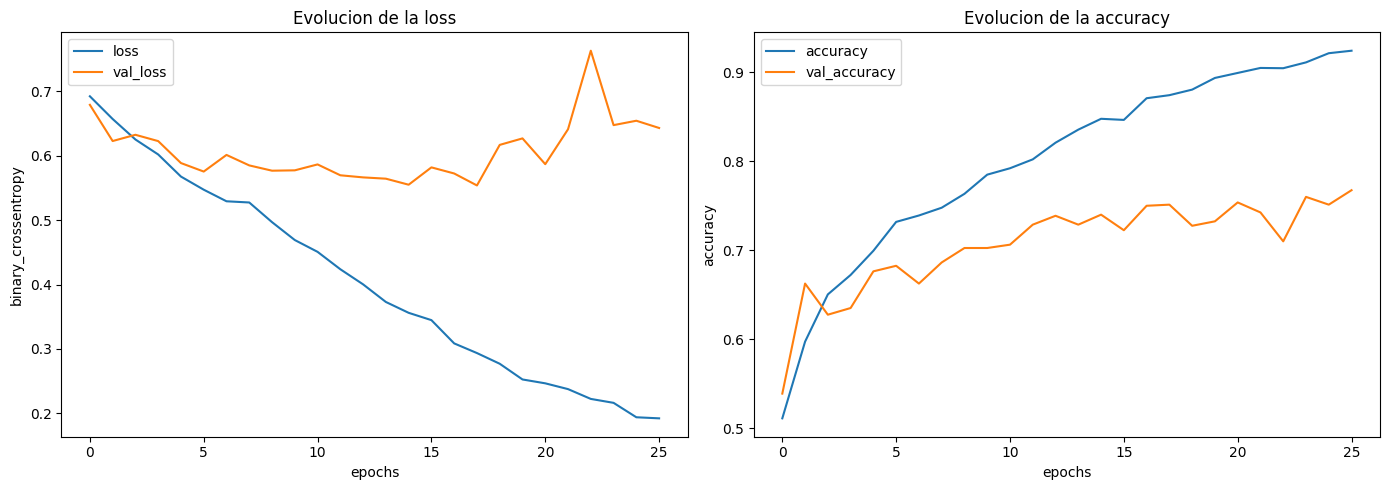

Epocas entrenadas: 26
Mejor val_loss: 0.5539 (epoca 18)


In [19]:
history_df = pd.DataFrame(history.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Evolucion de la loss")
axes[0].set_xlabel("epochs")
axes[0].set_ylabel("binary_crossentropy")

history_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_title("Evolucion de la accuracy")
axes[1].set_xlabel("epochs")
axes[1].set_ylabel("accuracy")

plt.tight_layout()
plt.show()

print(f"Epocas entrenadas: {len(history_df)}")
print(f"Mejor val_loss: {history_df['val_loss'].min():.4f} "
      f"(epoca {history_df['val_loss'].idxmin() + 1})")

**Lectura del entrenamiento**

El EarlyStopping ha parado en la **época 26**, y la mejor `val_loss` (0.5539) la
consiguió en la **época 18**. Gracias a `restore_best_weights=True` el modelo que
nos queda es el de esa época 18, no el de la 26.

Lo interesante es ver **cómo se separan las curvas**:

| | accuracy train | accuracy validación | diferencia |
|---|---|---|---|
| época 18 (la mejor) | 0.874 | 0.751 | +12,3 puntos |
| época 26 (la última) | 0.924 | 0.768 | +15,7 puntos |

La accuracy de train sube sin parar hasta el 92%, mientras que la de validación se
queda estancada alrededor del 75-77%. Y la `val_loss`, después de la época 18,
empieza a **subir** aunque la de train siga bajando.

Eso es **overfitting** de libro: la red ha dejado de aprender patrones generales y
está memorizando las imágenes concretas del train. Y es esperable, porque 4000
imágenes son pocas para los ~355.000 parámetros del modelo.

Es justo el problema que intentaremos atacar en el apartado extra con el aumentado
de imágenes.

***
## 4. Evaluación del modelo

Evaluamos contra el conjunto de test (las 1000 imágenes de `github_test`, que el
modelo no ha visto nunca).

In [20]:
loss_test, accuracy_test = model.evaluate(X_test_esc, y_test_num, verbose=0)
print(f"Loss en test    : {loss_test:.4f}")
print(f"Accuracy en test: {accuracy_test:.4f}  ({accuracy_test:.1%})")

Loss en test    : 0.5371
Accuracy en test: 0.7490  (74.9%)


Ahora las predicciones. La red devuelve la **probabilidad de que sea perro**
(porque la salida es una sigmoid y "dog" es la clase 1). Para pasar de
probabilidad a clase aplicamos el umbral habitual de 0.5.

In [21]:
# probabilidades de la clase "dog" (la salida sigmoid), una por imagen
probs_dog = model.predict(X_test_esc, verbose=0).ravel()

# de probabilidad a clase con el umbral 0.5
y_pred_num = (probs_dog >= 0.5).astype(int)

print("Primeras 8 probabilidades de 'dog':", np.round(probs_dog[:8], 3))
print("Primeras 8 clases predichas       :", y_pred_num[:8])
print("Primeras 8 clases reales          :", y_test_num[:8])

Primeras 8 probabilidades de 'dog': [0.751 0.145 0.392 0.51  0.884 0.093 0.361 0.114]
Primeras 8 clases predichas       : [1 0 0 1 1 0 0 0]
Primeras 8 clases reales          : [0 0 0 0 0 0 0 0]


In [22]:
print(classification_report(y_test_num, y_pred_num, target_names=NOMBRES_CLASES))

              precision    recall  f1-score   support

         cat       0.79      0.68      0.73       500
         dog       0.72      0.82      0.76       500

    accuracy                           0.75      1000
   macro avg       0.75      0.75      0.75      1000
weighted avg       0.75      0.75      0.75      1000



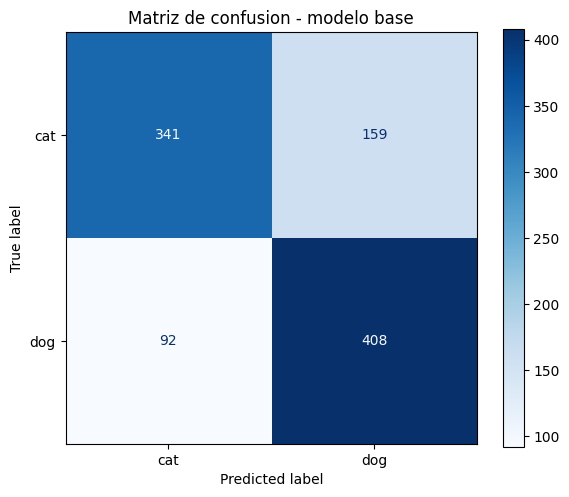

In [23]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_num,
    display_labels=NOMBRES_CLASES,
    cmap="Blues",
    ax=ax,
)
ax.set_title("Matriz de confusion - modelo base")
plt.tight_layout()
plt.show()

**Lectura de los resultados**

Accuracy en test: **74,9%**. Muy lejos del 99% del MNIST, pero hay que compararlo
con las dos referencias que tenemos:

| referencia | accuracy |
|---|---|
| azar | 50,0% |
| **baseline RandomForest** (apartado 2.4) | **61,7%** |
| **nuestra CNN** | **74,9%** |

La CNN le saca **13,2 puntos al RandomForest**. Eso es lo que aporta de verdad
aprovechar la estructura espacial de la imagen en lugar de tratarla como un vector
de píxeles sueltos. Sin ese baseline habríamos concluido "24,9 puntos por encima del
azar", que suena mejor pero informa peor.

Lo que más llama la atención del informe es que **el modelo no trata igual a las
dos clases**:

| clase | precision | recall | mal clasificadas |
|---|---|---|---|
| cat | 0.79 | **0.68** | 159 |
| dog | 0.72 | **0.82** | 92 |

El recall nos dice que pilla el 82% de los perros pero solo el 68% de los gatos.
Es decir, **el modelo tiende a decir "perro" cuando duda**: se le escapan casi el
doble de gatos (159) que de perros (92).

Esto pasa aunque el dataset esté perfectamente equilibrado, y tiene que ver con
que tenemos una única salida sigmoid con el umbral fijado en 0.5: el modelo ha
colocado su frontera de decisión desplazada hacia el lado de los gatos. Si nos
importara corregirlo, se podría **mover el umbral** (probar 0.55 o 0.6 en lugar de
0.5) y ver cómo se equilibran precision y recall.

En total quedan **251 imágenes mal clasificadas** de las 1000. Justo las que nos
interesan para el paso siguiente.

En la Unidad 2 veremos que con transfer learning (partiendo de una red ya
entrenada con millones de imágenes) este mismo problema se resuelve con mucha
mejor precisión.

***
## 5. Selección de las imágenes para el CAPTCHA

Recordemos el objetivo de negocio: queremos las imágenes que **peor** se le dan a
un sistema automático, para usarlas en el CAPTCHA. Las mejores candidatas no son
simplemente las que falla, sino aquellas en las que **falla estando muy seguro**:
si el modelo dice "esto es un gato con un 98% de confianza" y en realidad es un
perro, esa foto engaña al sistema de forma total.

Por tanto, el criterio es: de entre las mal clasificadas de cada clase, quedarnos
con las que tienen **la confianza más alta en la clase equivocada** (la predicha).

> **Nota sobre el enunciado**: el punto 5 dice primero "el mayor nivel de confianza
> de que pertenecían a la clase errónea" y luego lo aclara con "las imágenes de
> perros clasificadas como gatos y con la probabilidad de ser perro más alta". Las
> dos frases se contradicen (una pide confianza en la clase errónea, la otra en la
> correcta). Nos quedamos con **la primera**, que es la que tiene sentido para el
> objetivo de negocio: si la imagen es un perro clasificado como gato, lo que la
> hace difícil es que la probabilidad de *gato* sea muy alta.

Primero calculamos, para cada imagen, la confianza que el modelo tiene en la clase
que ha predicho.

In [24]:
# La red da la probabilidad de "dog". La de "cat" es 1 - esa.
# La confianza en la clase predicha es:
#   - si predijo dog (1) -> probs_dog
#   - si predijo cat (0) -> 1 - probs_dog
confianza_clase_predicha = np.where(y_pred_num == 1, probs_dog, 1 - probs_dog)

# Mascara de las mal clasificadas
mal_clasificadas = y_pred_num != y_test_num

print(f"Total mal clasificadas: {mal_clasificadas.sum()} de {len(y_test_num)}")
for numero, nombre in numero_a_clase.items():
    n = (mal_clasificadas & (y_test_num == numero)).sum()
    print(f"   {nombre} clasificados mal: {n}")

Total mal clasificadas: 251 de 1000
   cat clasificados mal: 159
   dog clasificados mal: 92


Y ahora seleccionamos el **10% de las mal clasificadas de cada clase**, las de
mayor confianza en la clase errónea.

In [25]:
PORCENTAJE = 0.10

seleccion_por_clase = {}

for numero, nombre in numero_a_clase.items():
    # indices de las imagenes de esta clase que estan mal clasificadas
    indices_mal = np.where(mal_clasificadas & (y_test_num == numero))[0]

    # cuantas nos quedamos (10%, al menos 1)
    n_seleccionar = max(1, int(round(PORCENTAJE * len(indices_mal))))

    # las ordenamos de mayor a menor confianza en la clase erronea y cogemos las primeras
    orden = np.argsort(-confianza_clase_predicha[indices_mal])
    seleccionadas = indices_mal[orden][:n_seleccionar]

    seleccion_por_clase[nombre] = seleccionadas

    print(f"{nombre}: {len(indices_mal)} mal clasificadas -> seleccionamos {n_seleccionar}")
    print(f"   confianza en la clase erronea: "
          f"de {confianza_clase_predicha[seleccionadas].min():.4f} "
          f"a {confianza_clase_predicha[seleccionadas].max():.4f}")

cat: 159 mal clasificadas -> seleccionamos 16
   confianza en la clase erronea: de 0.9267 a 0.9998
dog: 92 mal clasificadas -> seleccionamos 9
   confianza en la clase erronea: de 0.9572 a 0.9949


Las juntamos en una tabla para tener el listado final, que es el entregable de
negocio: los nombres de fichero que la empresa debería usar en su CAPTCHA.

In [26]:
filas = []
for nombre_clase, indices in seleccion_por_clase.items():
    for i in indices:
        filas.append({
            "fichero": nombres_test[i],
            "clase_real": numero_a_clase[y_test_num[i]],
            "clase_predicha": numero_a_clase[y_pred_num[i]],
            "confianza_en_clase_erronea": round(float(confianza_clase_predicha[i]), 4),
        })

df_seleccion = pd.DataFrame(filas).sort_values(
    "confianza_en_clase_erronea", ascending=False
).reset_index(drop=True)

print(f"Total de imagenes seleccionadas para el CAPTCHA: {len(df_seleccion)}")
df_seleccion

Total de imagenes seleccionadas para el CAPTCHA: 25


,fichero,clase_real,clase_predicha,confianza_en_clase_erronea
0,cat.11793.jpg,cat,dog,0.9998
1,cat.11867.jpg,cat,dog,0.9976
2,dog.9449.jpg,dog,cat,0.9949
3,dog.8764.jpg,dog,cat,0.9914
4,dog.9346.jpg,dog,cat,0.9902
5,cat.11739.jpg,cat,dog,0.9888
6,cat.11929.jpg,cat,dog,0.9851
7,cat.11462.jpg,cat,dog,0.9837
8,dog.9876.jpg,dog,cat,0.9788
9,cat.10921.jpg,cat,dog,0.9681


Y las vemos, que es lo más interesante del ejercicio: entender **por qué** son
difíciles.

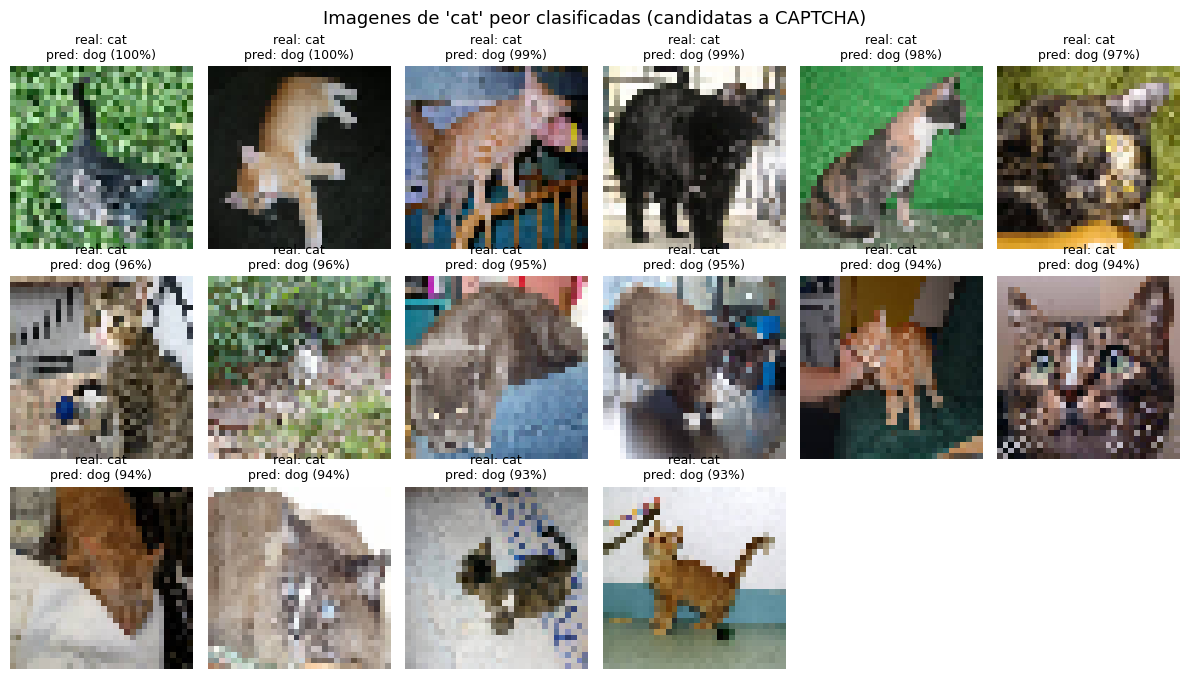

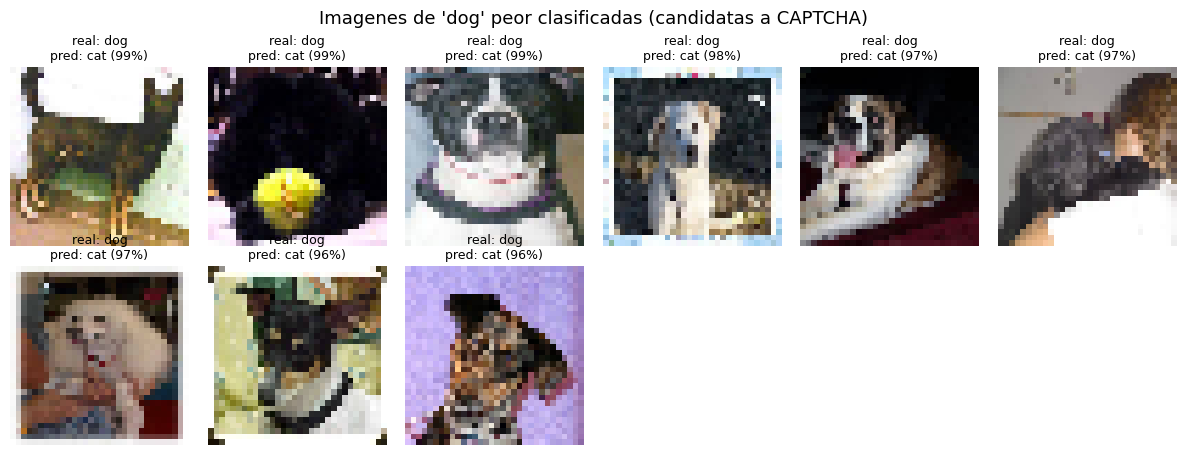

In [27]:
for nombre_clase, indices in seleccion_por_clase.items():
    etiquetas = [
        f"real: {numero_a_clase[y_test_num[i]]}\n"
        f"pred: {numero_a_clase[y_pred_num[i]]} ({confianza_clase_predicha[i]:.0%})"
        for i in indices
    ]
    plot_imagenes(
        X_test[indices], etiquetas, n_cols=6,
        titulo=f"Imagenes de '{nombre_clase}' peor clasificadas (candidatas a CAPTCHA)",
    )

**Conclusiones del paso 5**

Se seleccionan **25 imágenes** (16 gatos + 9 perros, el 10% de las mal clasificadas
de cada clase). Las confianzas en la clase equivocada son altísimas: entre 0.927 y
**0.9998** en los gatos, y entre 0.957 y 0.995 en los perros.

La peor de todas es `cat.11793.jpg`: un gato que el modelo clasifica como perro con
un **99,98% de confianza**. Para el objetivo de negocio, esa es la foto perfecta.

Mirando las imágenes seleccionadas se entiende bastante bien por qué engañan al
modelo. Los patrones que se repiten:

* El animal **no es el protagonista** de la foto: aparece pequeño, lejos, o
  compartiendo espacio con personas u objetos.
* **Poses raras o encuadres parciales**: solo se ve una parte del animal, o está
  de espaldas, tumbado o muy tapado.
* **Fondos con mucha textura** que a 32x32 se confunden con el pelo del animal.
* Siluetas y tamaños ambiguos: gatos grandes que parecen perros pequeños y al
  revés.

Son exactamente las fotos que le recomendaríamos a la empresa para su CAPTCHA: un
humano las resuelve sin problema, pero un clasificador automático como el nuestro
falla en ellas **con una seguridad casi total**.

***
## Extra: repetir los pasos 3 a 5 con Image Augmentation

El enunciado pide usar el generador de imágenes sintéticas de Keras.

> **Nota de versión (importante)**: en este entorno hay **Keras 3.15**, y el import
> que aparece en los notebooks del curso falla:
>
> ```python
> from keras.preprocessing.image import ImageDataGenerator
> # ImportError: cannot import name 'ImageDataGenerator'
> ```
>
> La clase **no ha desaparecido**: sigue en Keras 3 como código legacy, en
> `keras.src.legacy.preprocessing.image`, y se llega a ella por el espacio de
> compatibilidad de TensorFlow. Este import **sí funciona**:
>
> ```python
> from tensorflow.keras.preprocessing.image import ImageDataGenerator
> ```
>
> Es decir, era cuestión de la ruta del import, no de la versión.
>
> Aun así, aquí resolvemos el aumentado con las **capas de aumentado** de Keras 3
> (`RandomFlip`, `RandomRotation`, `RandomZoom`), que son la API recomendada
> actualmente y hacen lo mismo. La ventaja es que el aumentado va dentro del
> modelo, así que viaja con él y no hay que montar generadores aparte.
>
> Detalle importante: **estas capas solo actúan durante el entrenamiento**. En
> `evaluate` y `predict` se desactivan solas, igual que el Dropout.

Qué aumentados tienen sentido aquí:

* `RandomFlip("horizontal")`: un perro mirando a la izquierda sigue siendo un
  perro mirando a la derecha. **Solo horizontal**: un volteo vertical daría perros
  boca abajo, que no es algo que vayamos a encontrar en fotos reales.
* `RandomRotation(0.1)`: giros de hasta un 10% de vuelta (unos 36 grados), para
  cubrir fotos algo torcidas.
* `RandomZoom(0.1)`: acerca o aleja un 10%, para cubrir animales más cerca o más
  lejos de la cámara.

No tocamos el color ni volteamos en vertical para no generar imágenes que no se
parezcan a las reales.

In [28]:
# Construimos el mismo modelo, pero con las capas de aumentado al principio
model_aug = Sequential([
    Input(shape=(32, 32, 3)),

    # --- Capas de aumentado: solo actuan durante el entrenamiento ---
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),

    # --- El resto es identico al modelo base, para poder comparar ---
    Conv2D(filters=32, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),

    Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"),
    MaxPooling2D(pool_size=(2, 2)),
    Dropout(0.25),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(1, activation="sigmoid"),
])

model_aug.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"],
)

model_aug.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ random_flip (RandomFlip)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation                 │ (None, 32, 32, 3)      │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_zoom (RandomZoom)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       262,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 355,649 (1.36 MB)

 Trainable params: 355,649 (1.36 MB)

 Non-trainable params: 0 (0.00 B)

Fíjate en que el número de parámetros es **el mismo** que antes: las capas de
aumentado no tienen pesos que entrenar, solo transforman las imágenes.

Antes de entrenar, comprobamos que el aumentado hace lo que esperamos. Pasamos la
misma imagen varias veces por las capas de aumentado con `training=True` para
forzar que se apliquen.

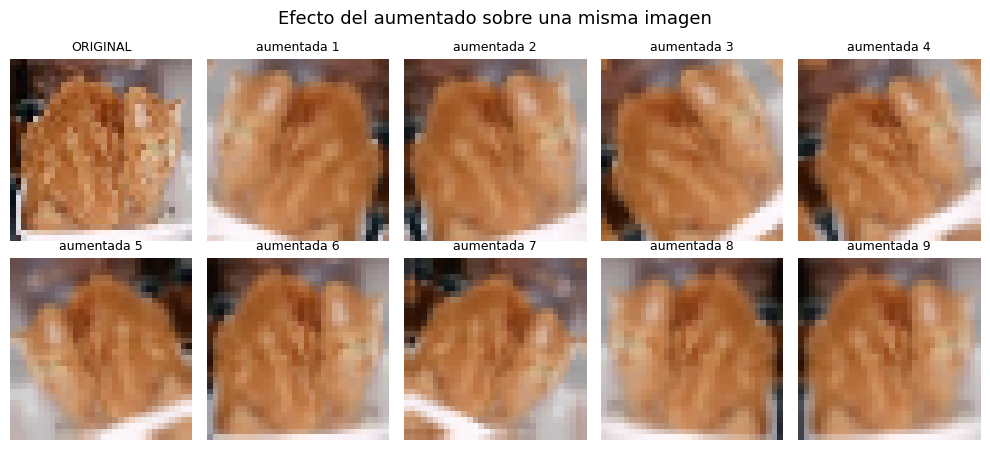

In [29]:
# Cogemos una imagen y le aplicamos el aumentado 10 veces para ver la variedad
capas_aumentado = Sequential([
    RandomFlip("horizontal"),
    RandomRotation(0.1),
    RandomZoom(0.1),
])

imagen_ejemplo = X_train_esc[0]
lote = np.expand_dims(imagen_ejemplo, axis=0)

# training=True fuerza a que las capas de aumentado se apliquen
versiones = [imagen_ejemplo] + [
    np.array(capas_aumentado(lote, training=True))[0] for _ in range(9)
]
etiquetas = ["ORIGINAL"] + [f"aumentada {i}" for i in range(1, 10)]

plot_imagenes(np.array(versiones), etiquetas, n_cols=5,
              titulo="Efecto del aumentado sobre una misma imagen")

Se ve el efecto: volteos horizontales, ligeras rotaciones y zooms. Con esto el
modelo nunca ve exactamente la misma imagen dos veces, y le cuesta más
memorizarlas.

### Entrenamiento del modelo con aumentado

Subimos la `patience` a 12 porque con aumentado el entrenamiento es más ruidoso y
tarda más en converger: si dejamos la paciencia baja, el EarlyStopping podría
cortar demasiado pronto en un bache.

In [30]:
early_stopping_aug = EarlyStopping(
    monitor="val_loss",
    patience=12,
    restore_best_weights=True,
    verbose=1,
)

history_aug = model_aug.fit(
    X_train_esc, y_train_num,
    batch_size=64,
    epochs=80,
    validation_split=0.2,
    callbacks=[early_stopping_aug],
    verbose=2,
)

Epoch 1/80


50/50 - 3s - 68ms/step - accuracy: 0.5047 - loss: 0.6960 - val_accuracy: 0.5875 - val_loss: 0.6904


Epoch 2/80


50/50 - 1s - 30ms/step - accuracy: 0.5525 - loss: 0.6855 - val_accuracy: 0.5075 - val_loss: 0.6859


Epoch 3/80


...

50/50 - 3s - 57ms/step - accuracy: 0.7725 - loss: 0.4740 - val_accuracy: 0.7125 - val_loss: 0.6014


Epoch 27/80


50/50 - 3s - 55ms/step - accuracy: 0.7697 - loss: 0.4744 - val_accuracy: 0.6950 - val_loss: 0.5913


Epoch 27: early stopping


Restoring model weights from the end of the best epoch: 15.


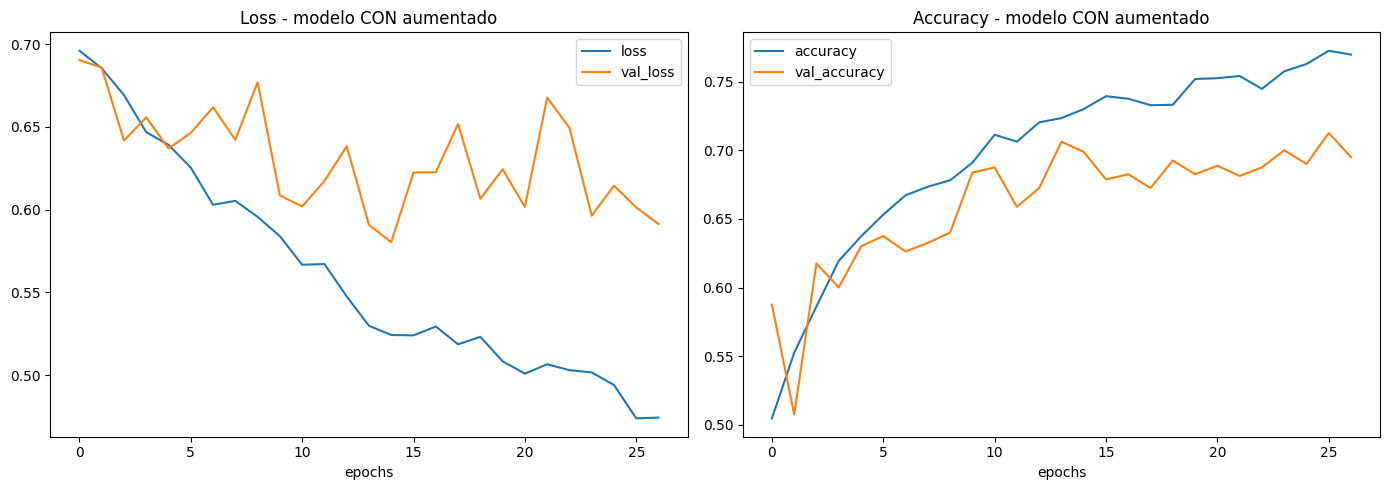

Epocas entrenadas: 27
Mejor val_loss: 0.5804 (epoca 15)


In [31]:
history_aug_df = pd.DataFrame(history_aug.history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

history_aug_df[["loss", "val_loss"]].plot(ax=axes[0])
axes[0].set_title("Loss - modelo CON aumentado")
axes[0].set_xlabel("epochs")

history_aug_df[["accuracy", "val_accuracy"]].plot(ax=axes[1])
axes[1].set_title("Accuracy - modelo CON aumentado")
axes[1].set_xlabel("epochs")

plt.tight_layout()
plt.show()

print(f"Epocas entrenadas: {len(history_aug_df)}")
print(f"Mejor val_loss: {history_aug_df['val_loss'].min():.4f} "
      f"(epoca {history_aug_df['val_loss'].idxmin() + 1})")

**El aumentado ha hecho su trabajo contra el overfitting.** Comparando las dos
gráficas se ve que aquí las curvas de train y validación van **mucho más pegadas**:

| | accuracy train | accuracy validación | diferencia |
|---|---|---|---|
| modelo base, mejor época | 0.874 | 0.751 | +12,3 puntos |
| modelo con aumentado, mejor época | 0.730 | 0.699 | **+3,1 puntos** |

La separación entre train y validación se ha reducido de 12,3 a 3,1 puntos. El
modelo ya no puede memorizar las imágenes, porque cada época las ve giradas,
volteadas o con otro zoom.

Fíjate también en que la accuracy de train **ya no llega al 92%** como antes: se
queda en el 73%. Eso es exactamente lo que hace un regularizador: le pone las
cosas más difíciles al modelo durante el entrenamiento.

### Evaluación del modelo con aumentado

In [32]:
loss_test_aug, accuracy_test_aug = model_aug.evaluate(X_test_esc, y_test_num, verbose=0)
print(f"Loss en test    : {loss_test_aug:.4f}")
print(f"Accuracy en test: {accuracy_test_aug:.4f}  ({accuracy_test_aug:.1%})")

probs_dog_aug = model_aug.predict(X_test_esc, verbose=0).ravel()
y_pred_num_aug = (probs_dog_aug >= 0.5).astype(int)

print()
print(classification_report(y_test_num, y_pred_num_aug, target_names=NOMBRES_CLASES))

Loss en test    : 0.5727
Accuracy en test: 0.6920  (69.2%)



              precision    recall  f1-score   support

         cat       0.82      0.50      0.62       500
         dog       0.64      0.89      0.74       500

    accuracy                           0.69      1000
   macro avg       0.73      0.69      0.68      1000
weighted avg       0.73      0.69      0.68      1000



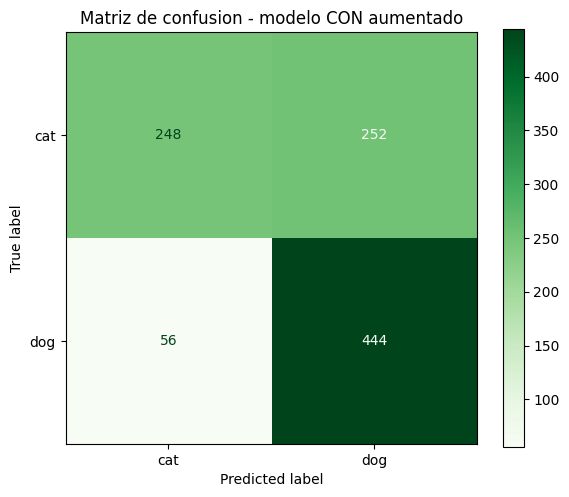

In [33]:
fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test_num, y_pred_num_aug,
    display_labels=NOMBRES_CLASES,
    cmap="Greens",
    ax=ax,
)
ax.set_title("Matriz de confusion - modelo CON aumentado")
plt.tight_layout()
plt.show()

### Comparativa de los dos modelos

Juntamos las métricas de los dos en una tabla para verlo todo de golpe.

In [34]:
comparativa = pd.DataFrame({
    "modelo": ["Base (sin aumentado)", "Con aumentado"],
    "epocas": [len(history_df), len(history_aug_df)],
    "mejor_val_loss": [round(history_df["val_loss"].min(), 4),
                       round(history_aug_df["val_loss"].min(), 4)],
    "loss_test": [round(loss_test, 4), round(loss_test_aug, 4)],
    "accuracy_test": [round(accuracy_test, 4), round(accuracy_test_aug, 4)],
    "mal_clasificadas": [int((y_pred_num != y_test_num).sum()),
                         int((y_pred_num_aug != y_test_num).sum())],
})
comparativa

,modelo,epocas,mejor_val_loss,loss_test,accuracy_test,mal_clasificadas
0,Base (sin aumentado),26,0.5539,0.5371,0.749,251
1,Con aumentado,27,0.5804,0.5727,0.692,308


**Lectura de la comparativa (y aquí viene lo interesante)**

El resultado no es el que esperaba: el modelo con aumentado **generaliza mejor pero
puntúa peor**.

* A favor del aumentado: la diferencia train-validación se hundió de 12,3 a 3,1
  puntos. El overfitting prácticamente ha desaparecido.
* En contra: la accuracy en test **baja** del 74,9% al 69,2%, y las mal clasificadas
  suben de 251 a 308.

¿Cómo se explica? Hemos cambiado **varianza por sesgo**. El modelo base memorizaba
(varianza alta); el aumentado ya no memoriza, pero se ha quedado corto de
aprendizaje: su accuracy en train se queda en el 73%, cuando el base llegaba al
92%. Ahora el problema no es que sobre-ajuste, es que **no llega**.

Se ve muy bien en el desequilibrio entre clases, que **empeora** con el aumentado:
el recall de `cat` cae de 0.68 a **0.50**, o sea que se le escapa la mitad de los
gatos. El modelo, con menos capacidad de aprendizaje, se refugia en responder
"perro".

La causa más probable está en el tamaño de las imágenes. A 32x32:

* `RandomRotation(0.1)` gira la imagen y mete **bordes negros**, comiéndose parte
  de los pocos píxeles útiles que hay.
* `RandomZoom(0.1)` recorta o estira, y a esta resolución cada píxel cuenta.
* Encima el modelo ya llevaba **tres capas de Dropout**. Sumar aumentado a eso es
  regularizar dos veces.

Es decir: el aumentado funciona como regularizador, pero las transformaciones que
hemos elegido son demasiado agresivas para imágenes tan pequeñas. Lo lógico sería
probar solo `RandomFlip("horizontal")`, que es el único aumentado que **no destruye
información** (una imagen reflejada conserva todos sus píxeles).

Lo dejamos así porque el resultado es en sí mismo una conclusión útil: el aumentado
de imágenes no es un interruptor que siempre mejora, hay que ajustarlo al problema.

### Nueva selección de imágenes para el CAPTCHA

Repetimos el paso 5 con el modelo aumentado. Aunque su accuracy sea algo peor, es
un emulador interesante porque se equivoca de forma **distinta** al primero, y eso
nos permite cruzar las dos selecciones.

In [35]:
confianza_aug = np.where(y_pred_num_aug == 1, probs_dog_aug, 1 - probs_dog_aug)
mal_clasificadas_aug = y_pred_num_aug != y_test_num

seleccion_aug = {}

for numero, nombre in numero_a_clase.items():
    indices_mal = np.where(mal_clasificadas_aug & (y_test_num == numero))[0]
    n_seleccionar = max(1, int(round(PORCENTAJE * len(indices_mal))))
    orden = np.argsort(-confianza_aug[indices_mal])
    seleccion_aug[nombre] = indices_mal[orden][:n_seleccionar]

    print(f"{nombre}: {len(indices_mal)} mal clasificadas -> seleccionamos {n_seleccionar}")

cat: 252 mal clasificadas -> seleccionamos 25
dog: 56 mal clasificadas -> seleccionamos 6


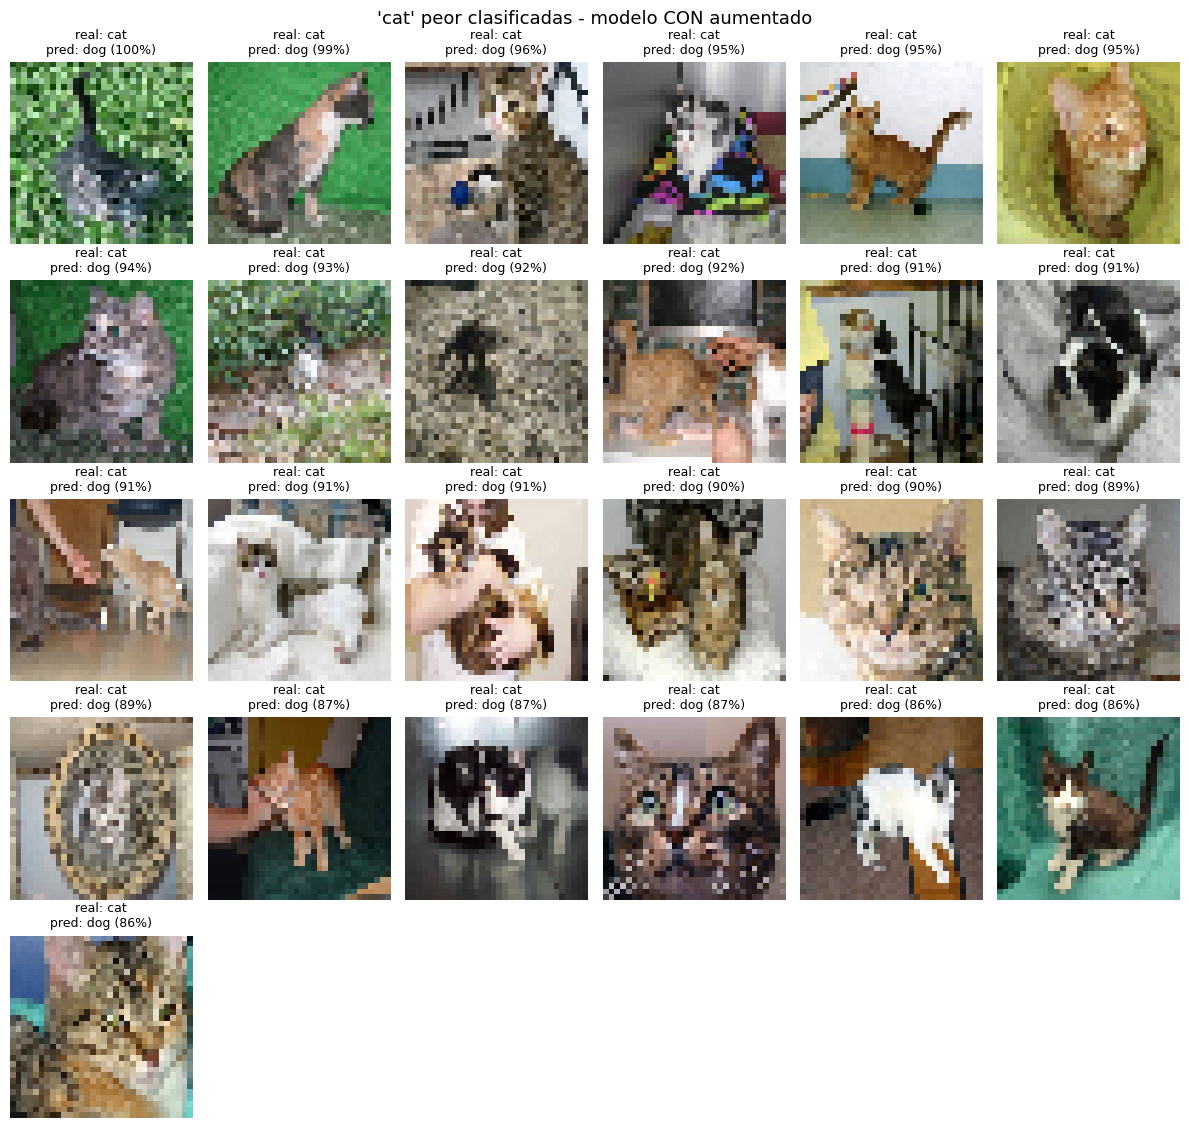

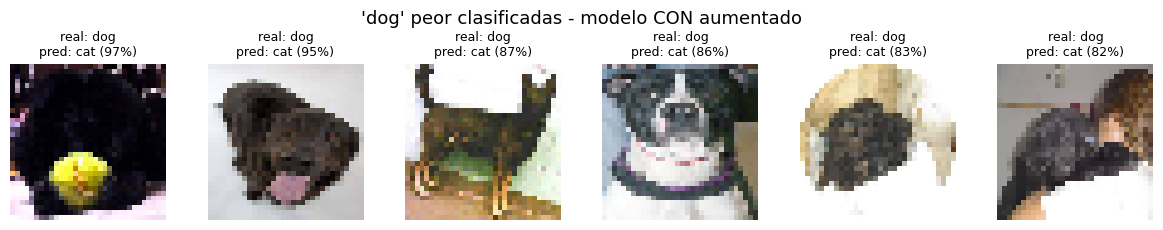

In [36]:
for nombre_clase, indices in seleccion_aug.items():
    etiquetas = [
        f"real: {numero_a_clase[y_test_num[i]]}\n"
        f"pred: {numero_a_clase[y_pred_num_aug[i]]} ({confianza_aug[i]:.0%})"
        for i in indices
    ]
    plot_imagenes(
        X_test[indices], etiquetas, n_cols=6,
        titulo=f"'{nombre_clase}' peor clasificadas - modelo CON aumentado",
    )

Seleccionadas por el modelo base : 25
Seleccionadas por el modelo aug  : 31
Coinciden en                     : 11 imagenes


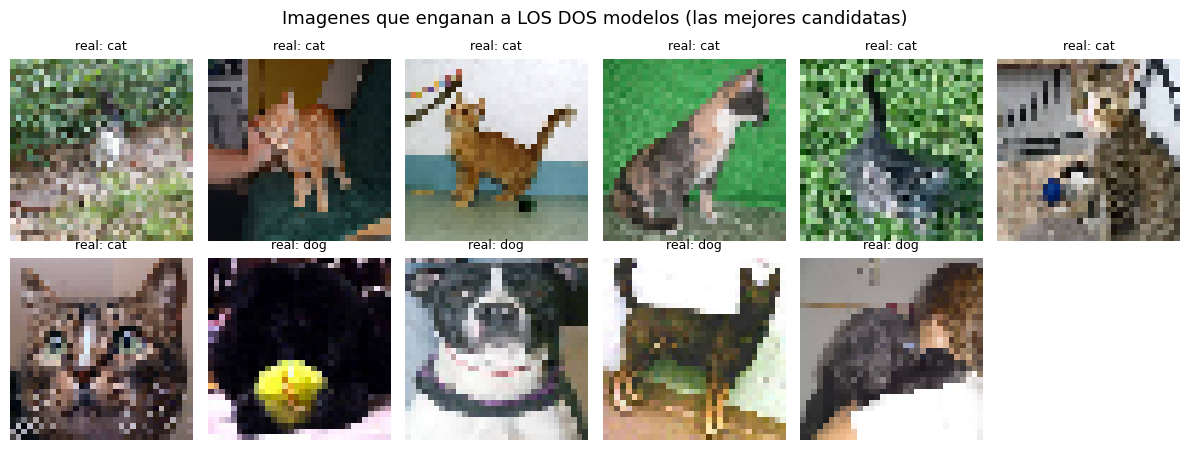

In [37]:
# Cuantas imagenes coinciden entre las dos selecciones?
set_base = set()
for indices in seleccion_por_clase.values():
    set_base.update(indices.tolist())

set_aug = set()
for indices in seleccion_aug.values():
    set_aug.update(indices.tolist())

comunes = set_base & set_aug
print(f"Seleccionadas por el modelo base : {len(set_base)}")
print(f"Seleccionadas por el modelo aug  : {len(set_aug)}")
print(f"Coinciden en                     : {len(comunes)} imagenes")

if comunes:
    indices_comunes = sorted(comunes)
    etiquetas = [f"real: {numero_a_clase[y_test_num[i]]}" for i in indices_comunes]
    plot_imagenes(X_test[indices_comunes], etiquetas, n_cols=6,
                  titulo="Imagenes que enganan a LOS DOS modelos (las mejores candidatas)")

***
## Conclusiones finales

**Sobre el modelo**

1. Una CNN sencilla de tres bloques Conv-Pool entrenada desde cero alcanza un
   **74,9% de accuracy** clasificando perros y gatos a 32x32.
2. Lo relevante es contra qué se compara. El **baseline con RandomForest sobre
   píxeles planos da 61,7%**, así que la CNN aporta **13,2 puntos** por aprovechar
   la estructura espacial. Frente al azar (50%) la mejora parecería de 24,9 puntos,
   pero eso sería engañarnos.
3. El **overfitting** era el problema principal: con 4000 imágenes y ~355.000
   parámetros, la red llega al 92% en train mientras se queda en el 75% en
   validación. El `EarlyStopping` con `restore_best_weights` es lo que evita que nos
   llevemos a casa un modelo ya degradado.
4. Los dos modelos **tienden a responder "perro" cuando dudan** (recall de 0.82 y
   0.89 en perros, frente a 0.68 y 0.50 en gatos). Ajustar el umbral de decisión de
   la sigmoid, en lugar de dejarlo en 0.5, sería lo primero que probaría para
   corregirlo.
5. El baseline nos dio además una pista útil: **RGB y escala de grises puntúan
   igual** (61,6% y 61,7%), así que en este problema el color no es informativo y
   todo el trabajo lo hace la forma.

**Sobre el aumentado de imágenes (y una conclusión que no esperaba)**

6. El aumentado **sí ha eliminado el overfitting**: la diferencia entre train y
   validación bajó de 12,3 a 3,1 puntos, y la accuracy de train dejó de dispararse
   hasta el 92%.
7. Pero, contra lo que esperaba, **la accuracy en test no ha mejorado**: pasó de
   74,9% a 69,2%, y las imágenes mal clasificadas subieron de 251 a 308. El
   aumentado ha cambiado un problema por otro: ha quitado varianza y ha añadido
   sesgo. El modelo aumentado se queda en un 73% de accuracy en train, o sea que
   ahora **le falta capacidad de aprendizaje**, no le sobra.
8. Mi explicación es que a 32x32 la rotación y el zoom son **demasiado
   destructivos**: al girar una imagen tan pequeña se meten bordes negros y se
   pierde una parte importante de los pocos píxeles que hay. Además el modelo ya
   llevaba tres capas de Dropout, así que sumar aumentado encima acaba
   sobre-regularizando.
9. Lo que probaría a continuación: un aumentado **más suave** (solo
   `RandomFlip("horizontal")`, que es el único que no destruye información), o subir
   la resolución antes de aumentar. La lección es que el aumentado no es gratis ni
   automático: hay que elegir transformaciones que tengan sentido para el tamaño y
   el tipo de imagen que tenemos.

**Sobre el objetivo de negocio**

10. El entregable son las **25 imágenes** en las que el modelo falla con más
    confianza (hasta el 99,98%). Al mirarlas se ve un patrón claro: animales
    pequeños dentro de la foto, poses o encuadres raros, y fondos con mucha textura.
    Casos que un humano resuelve sin esfuerzo y una CNN de este tipo no.
11. Las **11 imágenes que engañan a los dos modelos** son las mejores candidatas de
    todas: si dos clasificadores entrenados de forma distinta fallan en la misma
    foto, es razonable pensar que es intrínsecamente difícil y no un fallo puntual
    de un modelo concreto. Serían las primeras que le pasaría a la empresa.

**Limitaciones y siguientes pasos**

12. La resolución de 32x32 es la limitación más grande: se pierde casi todo el
    detalle (ojos, orejas, textura del pelo) que distingue un perro de un gato.
    Subir a 64x64 o 128x128 mejoraría bastante, a costa de más tiempo de cómputo.
13. El camino realista para este problema es el **transfer learning** de la Unidad
    2: partir de una red ya entrenada con millones de imágenes en lugar de aprender
    los bordes y las texturas desde cero con 4000 fotos.